# **RNN training procedure**


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    #update for your local path
    %cd /home/jacob/kalnet

/home/jacob/kalnet


In [2]:
#Imports

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from kalnet.model import KalmanRNN
from kalnet.task import KalmanFilteringTask
from kalnet.train import load_checkpoint, train
from kalnet.task_vec import KalmanFilteringTask as KalmanFilteringTask_vec
from kalnet.train_vec import train as train_vec


## RNN with batch_size = 10 (two gains)

Checkpoint: `checkpoints/kf_twogain_10batch.pt`


In [12]:
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={DEVICE}")
if DEVICE == "cpu":
    print("Note: CUDA unavailable here; full 50k run will be slower on CPU.")


device=cuda


In [ ]:
# Skip if there is already a trained network saved
result = train(
    max_iter=50_001,
    test_iter=2_501,
    batch_size=10,
    log_every=500,
    lr=2e-4,
    tr_cond="two_gains",
    test_cond="two_gains",
    seed=SEED,
    device=DEVICE,
    save_path="checkpoints/kf_twogain_10batch.pt",
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved kf_twogain_10batch.pt"
)


Batch #0; Frac. RMSE: 2.992296; Opt. RMSE: 0.843650; Net. RMSE: 3.368100
Batch #500; Frac. RMSE: 1.200594; Opt. RMSE: 0.596912; Net. RMSE: 1.313561
Batch #1000; Frac. RMSE: 0.662906; Opt. RMSE: 0.574624; Net. RMSE: 0.955545
Batch #1500; Frac. RMSE: 0.567271; Opt. RMSE: 0.591026; Net. RMSE: 0.926298
Batch #2000; Frac. RMSE: 0.480445; Opt. RMSE: 0.588331; Net. RMSE: 0.870992
Batch #2500; Frac. RMSE: 0.404036; Opt. RMSE: 0.590971; Net. RMSE: 0.829744
Batch #3000; Frac. RMSE: 0.355409; Opt. RMSE: 0.590998; Net. RMSE: 0.801044
Batch #3500; Frac. RMSE: 0.316685; Opt. RMSE: 0.598502; Net. RMSE: 0.788038
Batch #4000; Frac. RMSE: 0.299264; Opt. RMSE: 0.586618; Net. RMSE: 0.762172
Batch #4500; Frac. RMSE: 0.273984; Opt. RMSE: 0.583622; Net. RMSE: 0.743525
Batch #5000; Frac. RMSE: 0.233750; Opt. RMSE: 0.597669; Net. RMSE: 0.737374
Batch #5500; Frac. RMSE: 0.235582; Opt. RMSE: 0.588223; Net. RMSE: 0.726798
Batch #6000; Frac. RMSE: 0.226793; Opt. RMSE: 0.583635; Net. RMSE: 0.716000
Batch #6500; Fra

AttributeError: 'str' object has no attribute 'resolve'

Fractional RMSE learning curve

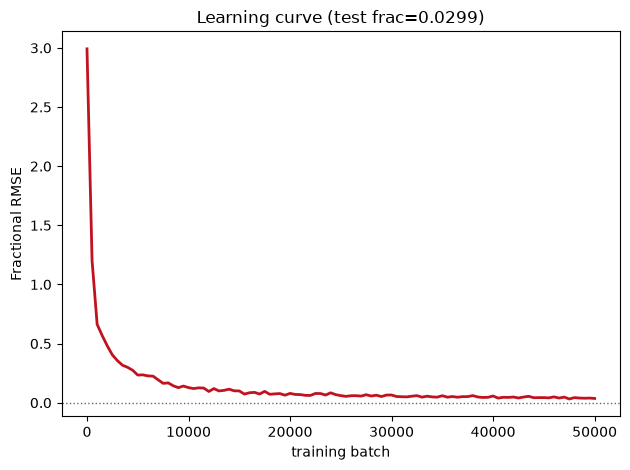

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 10,
 'lr': 0.0002,
 'tr_cond': 'two_gains',
 'test_cond': 'two_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 50001}

In [5]:
loaded = load_checkpoint(CHECKPOINT, device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg


Weights representation

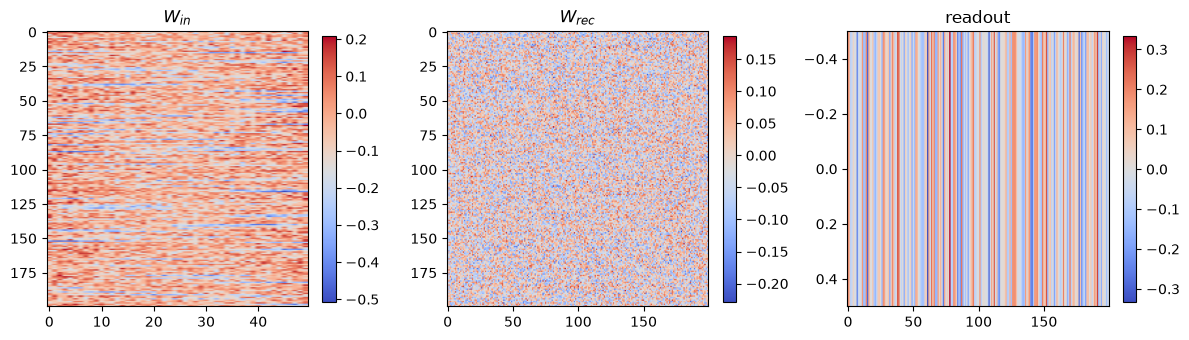

In [6]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [7]:
checkpoint = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="two_gains", seed=999)
batch = test_task.sample(include_internals=True)

x = torch.from_numpy(batch.input)
y_true = torch.from_numpy(batch.target)
y_opt = torch.from_numpy(batch.opt_mean)

with torch.no_grad():
    y_hat = net(x)

rmse_net = torch.sqrt(torch.mean((y_hat - y_true) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((y_opt - y_true) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")


Net RMSE:        0.5446
Optimal RMSE:    0.4487
Fractional RMSE: 21.37%


## RNN with batch=100 (two gains)

Checkpoint: `checkpoints/kf_twogain_100batch.pt`


In [8]:
# Skip if there is already a trained network saved
CHECKPOINT_100 = Path("checkpoints/kf_twogain_100batch.pt")
result = train_vec(
    batch_size=100,
    max_iter=20000,
    save_path=CHECKPOINT_100,
    tr_cond="two_gains",
    test_cond="two_gains",
    seed=SEED,
    device=DEVICE,
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved {CHECKPOINT_100.resolve()}"
)


Batch #0; Frac. RMSE: 3.418283; Opt. RMSE: 0.601140; Net. RMSE: 2.656008
Batch #500; Frac. RMSE: 0.594371; Opt. RMSE: 0.591282; Net. RMSE: 0.942723
Batch #1000; Frac. RMSE: 0.190128; Opt. RMSE: 0.590370; Net. RMSE: 0.702615
Batch #1500; Frac. RMSE: 0.103839; Opt. RMSE: 0.589419; Net. RMSE: 0.650624
Batch #2000; Frac. RMSE: 0.069929; Opt. RMSE: 0.588938; Net. RMSE: 0.630122
Batch #2500; Frac. RMSE: 0.051768; Opt. RMSE: 0.589332; Net. RMSE: 0.619841
Batch #3000; Frac. RMSE: 0.042094; Opt. RMSE: 0.589095; Net. RMSE: 0.613892
Batch #3500; Frac. RMSE: 0.034359; Opt. RMSE: 0.590015; Net. RMSE: 0.610287
Batch #4000; Frac. RMSE: 0.029047; Opt. RMSE: 0.590520; Net. RMSE: 0.607672
Batch #4500; Frac. RMSE: 0.025476; Opt. RMSE: 0.589789; Net. RMSE: 0.604815
Batch #5000; Frac. RMSE: 0.021201; Opt. RMSE: 0.589696; Net. RMSE: 0.602198
Batch #5500; Frac. RMSE: 0.018753; Opt. RMSE: 0.590486; Net. RMSE: 0.601559
Batch #6000; Frac. RMSE: 0.016514; Opt. RMSE: 0.590048; Net. RMSE: 0.599792
Batch #6500; Fra

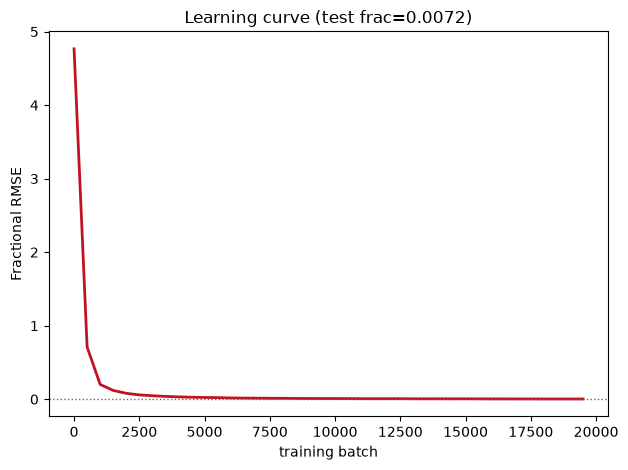

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 100,
 'lr': 0.0003,
 'l2_penalty': 1e-06,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 20000}

In [20]:
loaded = load_checkpoint(CHECKPOINT_100, device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg


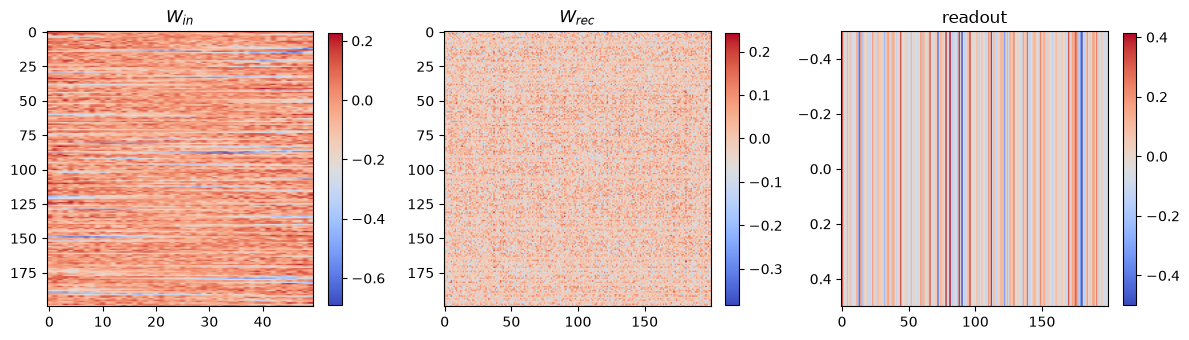

In [21]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [11]:
checkpoint = torch.load(CHECKPOINT_100, map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask_vec(batch_size=2000, tr_cond="two_gains", seed=999)
batch = test_task.sample(include_internals=True)

with torch.no_grad():
    y_hat = net(batch.input)  # (batch, T, 1)

rmse_net = torch.sqrt(torch.mean((y_hat - batch.target) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((batch.opt_mean - batch.target) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")


Net RMSE:        0.4591
Optimal RMSE:    0.4564
Fractional RMSE: 0.58%
